# Lab 1: Базові алгоритми класифікації у Scikit-learn

**Датасет:** https://archive.ics.uci.edu/dataset/442/detection+of+iot+botnet+attacks+n+baiot

### 1) Завантаження та первинний аналіз даних: завантажити датасет; вивести назви колонок та розмір датасета; визначити ознаки (features) та цільову змінну (target); перевірити типи даних та розподіл об'єктів за класами.

In [140]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

### Файли датасету

In [141]:
DATA_DIR = Path("../detection+of+iot+botnet+attacks+n+baiot/Danmini_Doorbell")

benign_file = DATA_DIR / 'benign_traffic.csv'
gafgyt_files = sorted((DATA_DIR / 'gafgyt_attacks').rglob('*.csv'))
mirai_files = sorted((DATA_DIR / 'mirai_attacks').rglob('*.csv'))

assert benign_file.exists(), f'Не знайдено файл {benign_file.resolve()}'
assert len(gafgyt_files) == 5, f'Очікувалось 5 CSV у gafgyt_attacks, знайдено {len(gafgyt_files)}'
assert len(mirai_files) == 5, f'Очікувалось 5 CSV у mirai_attacks, знайдено {len(mirai_files)}'

print('Папка з даними:', DATA_DIR.resolve())
for f in [benign_file, *gafgyt_files, *mirai_files]:
    print(f'  {f.relative_to(DATA_DIR)!s:<30} {f.stat().st_size / 1e6:7.1f} MB')

Папка з даними: C:\Users\komputer\Desktop\5_course\iad\detection+of+iot+botnet+attacks+n+baiot\Danmini_Doorbell
  benign_traffic.csv                46.5 MB
  gafgyt_attacks\combo.csv         105.8 MB
  gafgyt_attacks\junk.csv           49.3 MB
  gafgyt_attacks\scan.csv           40.2 MB
  gafgyt_attacks\tcp.csv            51.9 MB
  gafgyt_attacks\udp.csv            59.6 MB
  mirai_attacks\ack.csv            135.5 MB
  mirai_attacks\scan.csv           107.5 MB
  mirai_attacks\syn.csv            164.6 MB
  mirai_attacks\udp.csv            315.3 MB
  mirai_attacks\udpplain.csv       120.4 MB


### Формування датасету для подальшого аналізу

У самих файлах немає колонки з типом трафіку, він визначається назвою файлу. Тому під час завантаження додам дві колонки:
- `category`: загальний тип трафіку (`benign`, `gafgyt`, `mirai`);
- `label`: конкретний тип атаки, наприклад `gafgyt_combo` або `mirai_syn` (для нормального трафіку `benign`).

In [142]:
def load_csv(path, category, label):
    part = pd.read_csv(path).copy() 
    part['category'] = category
    part['label'] = label
    return part

parts = [load_csv(benign_file, 'benign', 'benign')]
for f in gafgyt_files:
    parts.append(load_csv(f, 'gafgyt', 'gafgyt_' + f.stem))
for f in mirai_files:
    parts.append(load_csv(f, 'mirai', 'mirai_' + f.stem))

df = pd.concat(parts, ignore_index=True)
del parts 

print(f'Завантажено {len(df):,} рядків')

Завантажено 1,018,298 рядків


### Розмір датасету та назви колонок

In [143]:
print(f'Розмір датасету: {df.shape[0]:,} рядків × {df.shape[1]} колонок')
print('Назви колонок:')
print(df.columns.tolist())

Розмір датасету: 1,018,298 рядків × 117 колонок
Назви колонок:
['MI_dir_L5_weight', 'MI_dir_L5_mean', 'MI_dir_L5_variance', 'MI_dir_L3_weight', 'MI_dir_L3_mean', 'MI_dir_L3_variance', 'MI_dir_L1_weight', 'MI_dir_L1_mean', 'MI_dir_L1_variance', 'MI_dir_L0.1_weight', 'MI_dir_L0.1_mean', 'MI_dir_L0.1_variance', 'MI_dir_L0.01_weight', 'MI_dir_L0.01_mean', 'MI_dir_L0.01_variance', 'H_L5_weight', 'H_L5_mean', 'H_L5_variance', 'H_L3_weight', 'H_L3_mean', 'H_L3_variance', 'H_L1_weight', 'H_L1_mean', 'H_L1_variance', 'H_L0.1_weight', 'H_L0.1_mean', 'H_L0.1_variance', 'H_L0.01_weight', 'H_L0.01_mean', 'H_L0.01_variance', 'HH_L5_weight', 'HH_L5_mean', 'HH_L5_std', 'HH_L5_magnitude', 'HH_L5_radius', 'HH_L5_covariance', 'HH_L5_pcc', 'HH_L3_weight', 'HH_L3_mean', 'HH_L3_std', 'HH_L3_magnitude', 'HH_L3_radius', 'HH_L3_covariance', 'HH_L3_pcc', 'HH_L1_weight', 'HH_L1_mean', 'HH_L1_std', 'HH_L1_magnitude', 'HH_L1_radius', 'HH_L1_covariance', 'HH_L1_pcc', 'HH_L0.1_weight', 'HH_L0.1_mean', 'HH_L0.1_std',

### **Назви колонок** 
Кожна назва має вигляд `<потік>_L<вікно>_<статистика>`, наприклад `MI_dir_L0.01_mean`.

| Частина | Значення |
|---|---|
| **Потік** | `H`: увесь трафік з IP пристрою; `MI_dir`: трафік з MAC+IP пристрою; `HH`: канал «пристрій - конкретний хост»; `HH_jit`: затримки між пакетами в цьому каналі; `HpHp`: канал «порт пристрою → порт хоста» |
| **Вікно** `L` | коефіцієнт згасання ковзного вікна: `L5` пам'ятає останні ~100 мс, `L0.01` приблизно хвилину |
| **Статистика** | `weight`: кількість пакетів у вікні; `mean`, `variance`, `std`: розмір пакетів (для `HH_jit` це затримки); `magnitude`, `radius`, `covariance`, `pcc`: порівняння вхідного та вихідного трафіку каналу |


In [144]:
feature_cols = [c for c in df.columns if c not in ('category', 'label')]

name_parts = pd.Series(feature_cols).str.extract(r'^(?P<потік>.+)_L(?P<вікно>[\d.]+)_(?P<статистика>\w+)$')
print('Часові вікна:', name_parts['вікно'].unique().tolist())
pd.crosstab(name_parts['потік'], name_parts['статистика'], margins=True, margins_name='всього')

Часові вікна: ['5', '3', '1', '0.1', '0.01']


статистика,covariance,magnitude,mean,pcc,radius,std,variance,weight,всього
потік,,,,,,,,,
H,0,0,5,0,0,0,5,5,15
HH,5,5,5,5,5,5,0,5,35
HH_jit,0,0,5,0,0,0,5,5,15
HpHp,5,5,5,5,5,5,0,5,35
MI_dir,0,0,5,0,0,0,5,5,15
всього,10,10,25,10,10,10,15,25,115


### Ознаки (features) та цільова змінна (target)

- **Ознаки `X`:** усі 115 числових колонок статистики трафіку.
- **Цільова змінна `y`:** колонка `label` з **11 класами**: нормальний трафік і 10 типів атак.
- Колонка `category`  не є ознакою для моделі, використовується лише для групування в аналізі й візуалізаціях.

In [145]:
TARGET = 'label'

X = df[feature_cols]
y = df[TARGET]

print('X:', X.shape, ' y:', y.shape)
print('Кількість ознак:', X.shape[1])
print('Кількість класів:', y.nunique())
print('Класи:', sorted(y.unique()))

X: (1018298, 115)  y: (1018298,)
Кількість ознак: 115
Кількість класів: 11
Класи: ['benign', 'gafgyt_combo', 'gafgyt_junk', 'gafgyt_scan', 'gafgyt_tcp', 'gafgyt_udp', 'mirai_ack', 'mirai_scan', 'mirai_syn', 'mirai_udp', 'mirai_udpplain']


### Типи даних

In [146]:
print('Типи колонок:')
print(df.dtypes.value_counts().to_string())
print('\nНечислові колонки:', df.select_dtypes(exclude='number').columns.tolist())

Типи колонок:
float64    115
str          2

Нечислові колонки: ['category', 'label']


In [147]:
stats = X.describe().T[['mean', 'std', 'min', 'max']]
ranges = stats.sort_values('max')
pd.concat([ranges.head(5), ranges.tail(5)])

,mean,std,min,max
HpHp_L5_pcc,3.958654e-06,1.775613e-03,-0.532289,5.042530e-01
HpHp_L3_pcc,5.857055e-06,1.959678e-03,-0.536021,5.837895e-01
HpHp_L1_pcc,1.144280e-05,2.478067e-03,-0.539767,7.000787e-01
HH_L5_pcc,2.901417e-05,2.883213e-03,-0.483815,7.014388e-01
HH_L3_pcc,8.128462e-05,4.521388e-03,-0.490352,7.091187e-01
HH_jit_L5_variance,5.373629e+13,4.797146e+15,0.000000,5.682564e+17
HH_jit_L3_variance,9.797175e+13,5.177431e+15,0.000000,5.682575e+17
HH_jit_L1_variance,2.052430e+15,2.148985e+16,0.000000,5.682580e+17
HH_jit_L0.1_variance,8.855193e+15,6.526146e+16,0.000000,5.682591e+17
HH_jit_L0.01_variance,9.961964e+15,7.130815e+16,0.000000,5.682592e+17


In [148]:
print('Ознак із від\'ємними значеннями:', (stats['min'] < 0).sum())
print(f"Найменший мінімум: {stats['min'].min():.3g}, найбільший максимум: {stats['max'].max():.3g}")

Ознак із від'ємними значеннями: 20
Найменший мінімум: -8.47e+04, найбільший максимум: 5.68e+17


### Розподіл об'єктів за класами

In [149]:
class_counts = (
    df.groupby(['category', 'label']).size()
      .rename('кількість').reset_index()
)
class_counts['частка, %'] = (class_counts['кількість'] / len(df) * 100).round(2)
class_counts

,category,label,кількість,"частка, %"
0,benign,benign,49548,4.87
1,gafgyt,gafgyt_combo,59718,5.86
2,gafgyt,gafgyt_junk,29068,2.85
3,gafgyt,gafgyt_scan,29849,2.93
4,gafgyt,gafgyt_tcp,92141,9.05
5,gafgyt,gafgyt_udp,105874,10.40
6,mirai,mirai_ack,102195,10.04
7,mirai,mirai_scan,107685,10.57
8,mirai,mirai_syn,122573,12.04
9,mirai,mirai_udp,237665,23.34


In [150]:
category_counts = df['category'].value_counts().rename('кількість').to_frame()
category_counts['частка, %'] = (category_counts['кількість'] / len(df) * 100).round(2)
category_counts

,кількість,"частка, %"
category,,
mirai,652100,64.04
gafgyt,316650,31.10
benign,49548,4.87


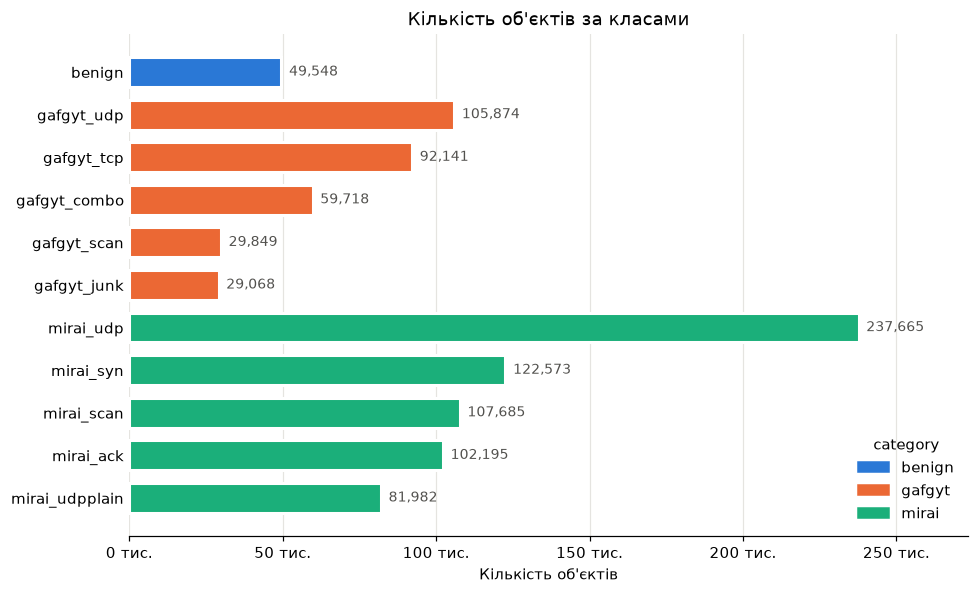

In [151]:
COLORS = {'benign': '#2a78d6', 'gafgyt': '#eb6834', 'mirai': '#1baf7a'}

plot_data = class_counts.sort_values(['category', 'кількість'], ascending=[False, True])

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=110)
bars = ax.barh(plot_data['label'], plot_data['кількість'], height=0.7,
               color=plot_data['category'].map(COLORS), edgecolor='white', linewidth=2)

for bar, n in zip(bars, plot_data['кількість']):
    ax.text(bar.get_width() + 2500, bar.get_y() + bar.get_height() / 2,
            f'{n:,}', va='center', fontsize=9, color='#52514e')

ax.set_title("Кількість об'єктів за класами", fontsize=12)
ax.set_xlabel("Кількість об'єктів")
ax.xaxis.set_major_formatter(lambda v, _: f'{v / 1000:.0f} тис.')
ax.set_xlim(0, plot_data['кількість'].max() * 1.15)
ax.grid(axis='x', color='#e5e4e0', linewidth=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.tick_params(axis='y', length=0)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()]
ax.legend(handles, COLORS.keys(), title='category', frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

In [152]:
counts = y.value_counts()
print(f'Найбільший клас: {counts.idxmax()} ({counts.max():,})')
print(f'Найменший клас:  {counts.idxmin()} ({counts.min():,})')

Найбільший клас: mirai_udp (237,665)
Найменший клас:  gafgyt_junk (29,068)


### 2) Попередня обробка даних: перевірити наявність пропущених значень; за необхідності заповнити або видалити пропуски; якщо датасет містить категоріальні ознаки, виконати їх кодування; коротко пояснити прийняті рішення щодо попередньої обробки даних.

### Наявність пропущених значень

In [153]:
missing = df.isnull().sum()
print('Пропущених значень (NaN) усього:', missing.sum())
print('Колонок із пропусками:', (missing > 0).sum())

n_inf = np.isinf(df[feature_cols]).sum().sum()
print('Нескінченних значень (inf):', n_inf)

Пропущених значень (NaN) усього: 0
Колонок із пропусками: 0
Нескінченних значень (inf): 0


### Дублікати

In [154]:
dup_mask = df.duplicated()
print(f'Повних дублікатів: {dup_mask.sum():,} ({dup_mask.mean():.1%} усіх рядків)')

print('\nДублікати за класами:')
print(df.loc[dup_mask, 'label'].value_counts().to_string())

Повних дублікатів: 21,759 (2.1% усіх рядків)

Дублікати за класами:
label
benign        9153
gafgyt_tcp    6914
gafgyt_udp    5692


In [155]:
df = df.drop_duplicates(ignore_index=True)
print(f'Після видалення дублікатів: {len(df):,} рядків')

Після видалення дублікатів: 996,539 рядків


### Категоріальні ознаки та кодування

In [156]:
print('Нечислові колонки серед ознак X:', df[feature_cols].select_dtypes(exclude='number').columns.tolist())

Нечислові колонки серед ознак X: []


Серед ознак категоріальних **немає**.

Текстовою є лише цільова змінна `label`. Присвоюється кожному класу номер від 0 до 10 (за алфавітом).

In [157]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_Encoded'] = le.fit_transform(df['label'])

pd.DataFrame({'label': le.classes_, 'target (код)': range(len(le.classes_))})

,label,target (код)
0,benign,0
1,gafgyt_combo,1
2,gafgyt_junk,2
3,gafgyt_scan,3
4,gafgyt_tcp,4
5,gafgyt_udp,5
6,mirai_ack,6
7,mirai_scan,7
8,mirai_syn,8
9,mirai_udp,9


In [158]:
df.head()

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,MI_dir_L0.1_mean,MI_dir_L0.1_variance,MI_dir_L0.01_weight,MI_dir_L0.01_mean,MI_dir_L0.01_variance,...,HpHp_L0.1_std,HpHp_L0.1_magnitude,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,category,label,label_Encoded
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,...,0.000000,60.00000,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,benign,benign,0
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,...,5.839096,346.61980,34.095047,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0,benign,benign,0
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,360.009198,35.999915,1.999693,360.000920,35.999999,...,10.004075,352.01884,100.081513,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0,benign,benign,0
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,...,0.000000,337.00000,0.000000,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0,benign,benign,0
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,197.966314,19181.965180,1.999230,198.446631,19182.247150,...,0.000000,60.00000,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,benign,benign,0


### 3) Візуалізація та дослідження даних - провести базовий Exploratory Data Analysis (EDA): побудувати heatmap кореляцій числових ознак; побудувати гістограми розподілу ознак; побудувати boxplot-и ознак відносно цільової змінної; коротко прокоментувати отримані візуалізації. Якщо ознак багато, для візуалізації можна обмежитися декількома найбільш інформативними.

In [159]:
import seaborn as sns

### Heatmap кореляцій усіх ознак

Рахуємо коефіцієнт кореляції Пірсона між кожною парою з 115 ознак.
Колонку `label_Encoded` у кореляцію не включаємо.

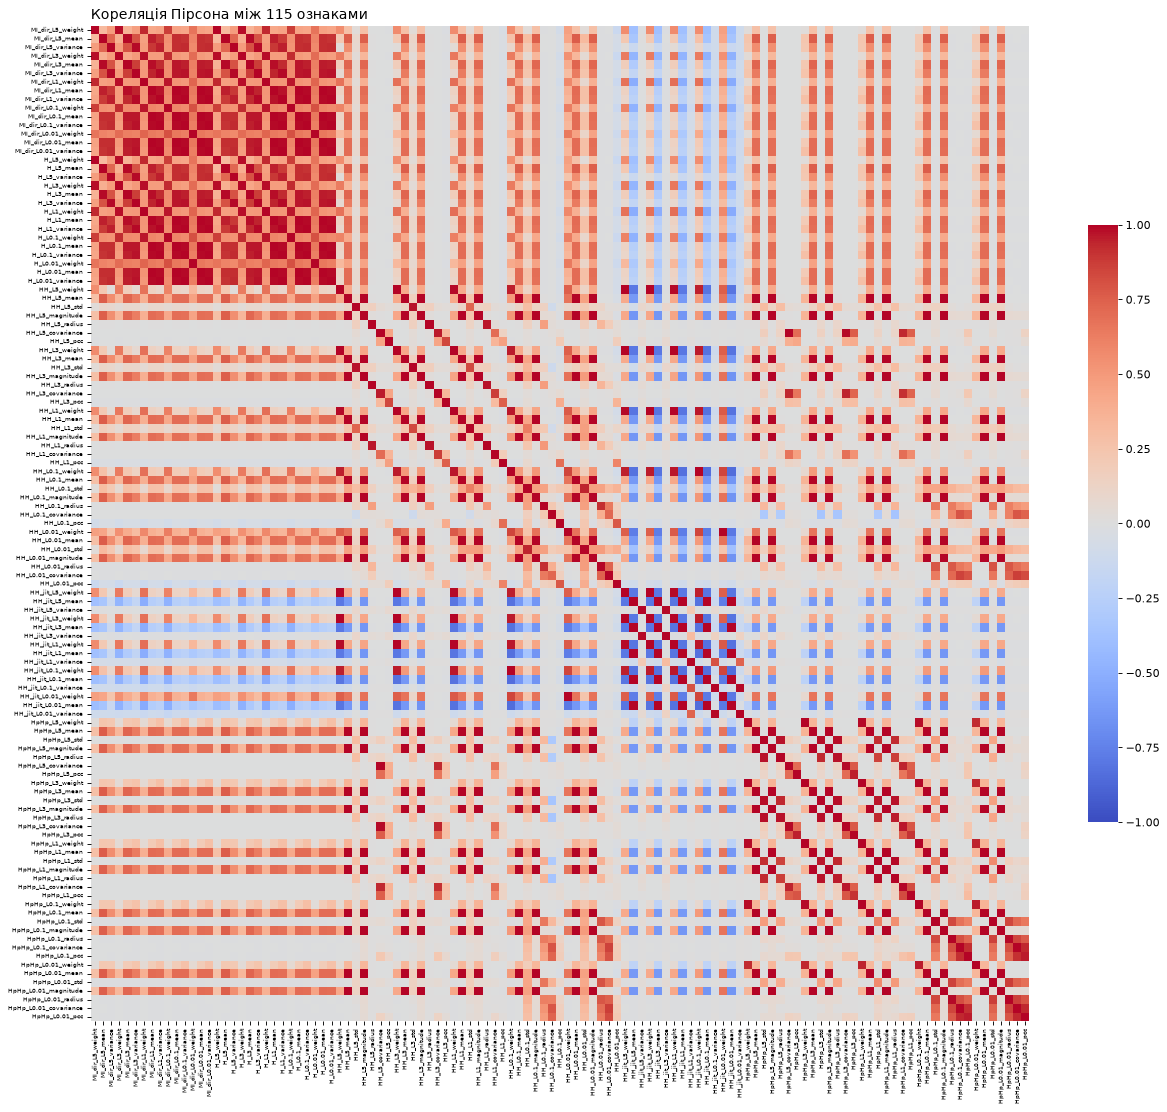

In [160]:
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14), dpi=80)
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.6}, ax=ax)
ax.tick_params(labelsize=5)
ax.set_title('Кореляція Пірсона між 115 ознаками', loc='left', fontsize=13)
plt.tight_layout()
plt.show()

In [161]:
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).abs()
n_pairs = upper.notna().sum().sum()
print(f'Усього пар ознак: {n_pairs:,}')
print(f'Пар із |r| > 0.95: {(upper > 0.95).sum().sum():,}')
print(f"Кореляція H_L0.01_mean і MI_dir_L0.01_mean: {corr.loc['H_L0.01_mean', 'MI_dir_L0.01_mean']:.4f}")

Усього пар ознак: 6,555
Пар із |r| > 0.95: 388
Кореляція H_L0.01_mean і MI_dir_L0.01_mean: 1.0000


**Що видно на heatmap:**
- **Блокова структура.** Ознаки групуються за потоками (`MI_dir`, `H`, `HH`, `HH_jit`, `HpHp`), і всередині груп кореляції сильні (темно-червоні квадрати).
- **`MI_dir` і `H` майже повністю дублюють одна одну:** великий червоний блок угорі ліворуч, а кореляція `H_L0.01_mean` і `MI_dir_L0.01_mean` дорівнює 1.0000.
  Це логічно: у дзвінка одна IP-адреса й одна MAC-адреса, тому «трафік з IP» і «трафік з MAC+IP» - той самий трафік.
- **Та сама статистика в різних часових вікнах** (L5 … L0.01) теж сильно корелює, що видно як повторювані червоні смуги.
- **388 з 6 555 пар мають |r| > 0.95,** тобто багато ознак надлишкові.
  Для дерев рішень це не проблема. У kNN майже однакові ознаки фактично отримують більшу вагу у відстані, але на якість сильно не впливають.
  Для навчання залишаємо всі 115 ознак, а для візуалізації обираємо неповторювані.
- **Сині ділянки** (від'ємна кореляція) пов'язані з ознаками `HH_jit` (затримки між пакетами): що більше пакетів, то менші інтервали між ними.
- **Сірі смуги** (r ≈ 0) - `covariance`, `pcc`, `radius`: у більшості записів вони дорівнюють 0 і майже не пов'язані з іншими ознаками.

### Вибір найінформативніших ознак

In [162]:
from sklearn.feature_selection import f_classif

f_scores, _ = f_classif(df[feature_cols], df['label'])
f_scores = pd.Series(f_scores, index=feature_cols).sort_values(ascending=False)

print('Топ-10 ознак за F-статистикою:')
print(f_scores.head(10).map('{:,.0f}'.format).to_string())

Топ-10 ознак за F-статистикою:
H_L0.01_mean             370,181,856
MI_dir_L0.01_mean        368,916,284
H_L0.1_mean              196,631,080
MI_dir_L0.1_mean         196,498,606
H_L0.01_variance          83,684,114
MI_dir_L0.01_variance     83,684,108
H_L0.1_variance           62,423,471
MI_dir_L0.1_variance      62,423,470
MI_dir_L1_variance        11,142,273
H_L1_variance             11,142,273


In [163]:
N_TOP = 8

top_features = []
for feature in f_scores.index:
    if all(abs(corr.loc[feature, chosen]) < 0.9 for chosen in top_features):
        top_features.append(feature)
    if len(top_features) == N_TOP:
        break

pd.DataFrame({'F-статистика': f_scores[top_features].map('{:,.0f}'.format)})

,F-статистика
H_L0.01_mean,"370,181,856"
MI_dir_L1_weight,"3,359,676"
MI_dir_L0.01_weight,"311,074"
HH_L3_weight,"213,179"
HH_jit_L0.01_variance,"155,370"
HpHp_L0.1_weight,"115,792"
HH_L0.01_mean,"96,694"
HH_jit_L0.01_mean,"93,340"


### Heatmap кореляцій обраних ознак

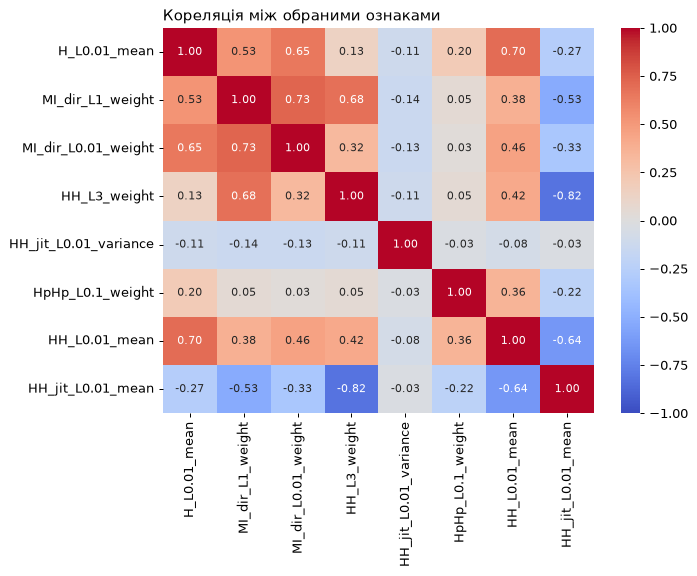

In [164]:
fig, ax = plt.subplots(figsize=(8, 6.5), dpi=90)
sns.heatmap(corr.loc[top_features, top_features], cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 9}, ax=ax)
ax.set_title('Кореляція між обраними ознаками', loc='left', fontsize=12)
plt.tight_layout()
plt.show()

За побудовою всі обрані ознаки мають між собою |r| < 0.9, тож кожна несе власну інформацію.
Найсильніший зв'язок: `HH_L3_weight` і `HH_jit_L0.01_mean`, r = −0.82. Що більше пакетів у каналі, то менші затримки між ними.
`HH_jit_L0.01_variance` майже не корелює з рештою ознак.

### Гістограми розподілу ознак

Спочатку подивимось на розподіли обраних ознак у вихідному вигляді.

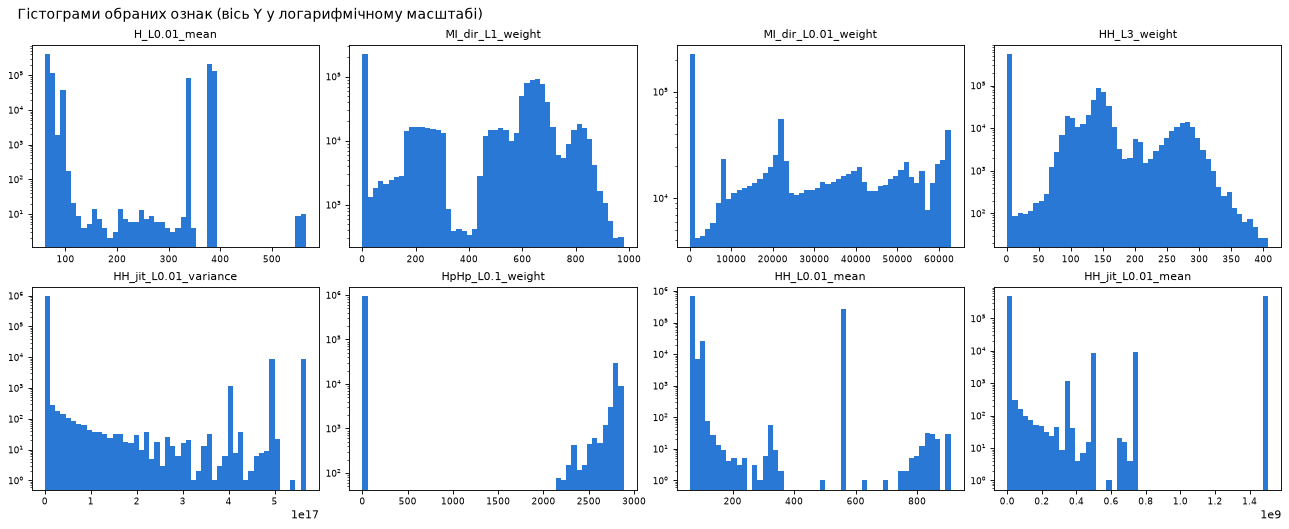

In [165]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5), dpi=80, layout='constrained')
for ax, feature in zip(axes.flat, top_features):
    ax.hist(df[feature], bins=50, color='#2a78d6')
    ax.set_title(feature, fontsize=10)
    ax.set_yscale('log')
    ax.tick_params(labelsize=8)
fig.suptitle('Гістограми обраних ознак (вісь Y у логарифмічному масштабі)', x=0.01, ha='left', fontsize=13)
plt.show()

**Висновки з гістограм:**
- Розподіли сильно скошені, мають кілька окремих піків і великі проміжки без значень. 
- Масштаби дуже різні, середній розмір пакета (`H_L0.01_mean`) лежить у межах 60–570, а `HH_jit_L0.01_variance` сягає 5·10¹⁷.
  Для kNN і SVM, які рахують відстані між об'єктами, це означає, що без масштабування ознака з найбільшими числами повністю «задавить» інші.

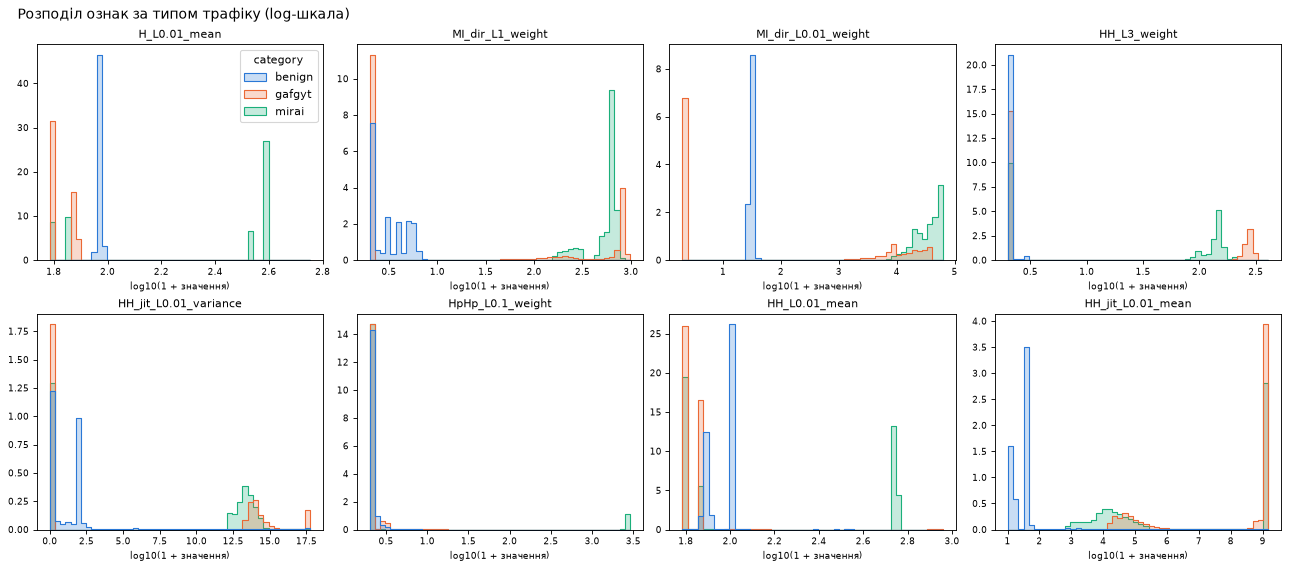

In [65]:
# log10(1 + x): переводимо значення в «порядки величини»; +1 потрібне, бо log(0) не визначений
log_df = np.log10(1 + df[top_features]).assign(category=df['category'], label=df['label'])

fig, axes = plt.subplots(2, 4, figsize=(16, 7), dpi=80, layout='constrained')
for i, (ax, feature) in enumerate(zip(axes.flat, top_features)):
    sns.histplot(data=log_df, x=feature, hue='category', palette=COLORS, bins=50,
                 stat='density', common_norm=False, element='step', ax=ax, legend=(i == 0))
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel('log10(1 + значення)', fontsize=8)
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)
fig.suptitle('Розподіл ознак за типом трафіку (log-шкала)', x=0.01, ha='left', fontsize=13)
plt.show()

**Висновки:** розподіли нормального трафіку та двох ботнетів здебільшого **не перекриваються**:
- **`H_L0.01_mean`** (середній розмір пакета): у нормального трафіку ≈ 93 байти (10^1.97). У Gafgyt 60–77 байт.
  У Mirai два піки: малі пакети (scan, syn) і великі ≈ 340–390 байт (ack, udp, udpplain).
- **`MI_dir_L0.01_weight`** (кількість пакетів приблизно за хвилину): у нормального трафіку ≈ 30 пакетів, а під час атак десятки тисяч, тобто в сотні й тисячі разів більше.
  Окремий пік Gafgyt біля 0.3 (`log10(2)`, тобто 1 пакет) дають атаки `gafgyt_tcp` і `gafgyt_udp`.
- **`HpHp_L0.1_weight`:** лише в Mirai є окремий пік біля 3.45 (≈ 2 800 пакетів в одному каналі «порт → порт»). Це атака `mirai_udpplain`, як видно з boxplot-ів нижче.
- **`HH_jit_L0.01_mean`:** нормальний трафік має малі значення, атаки великі.

Отже, навіть окремі ознаки добре відрізняють нормальний трафік від атак і Gafgyt від Mirai.

### Boxplot-и ознак відносно цільової змінної

Для кожної обраної ознаки будуємо boxplot за 11 класами `label`. Колір позначає ботнет.
Значення беремо у шкалі `log10(1 + x)`, інакше через величезний розкид більшість «ящиків» злипнеться біля нуля.

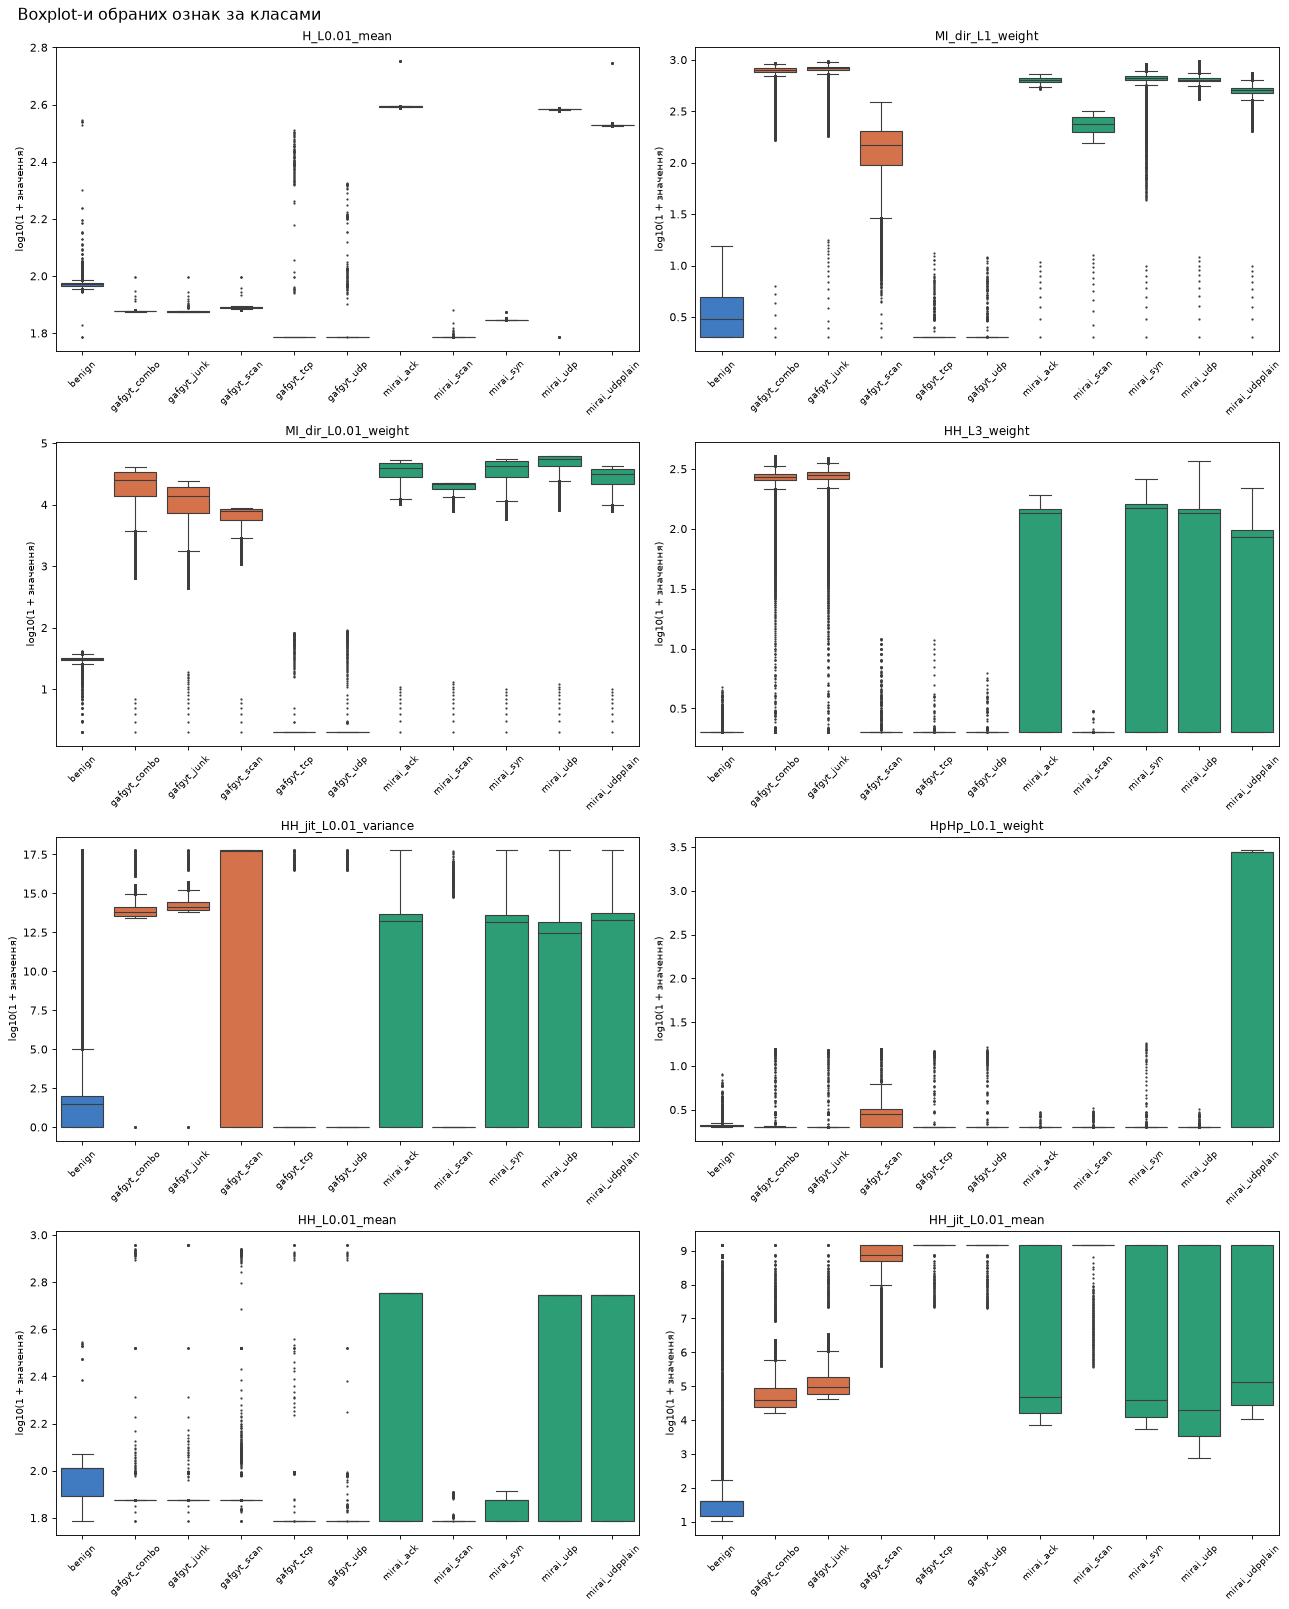

In [166]:
class_order = sorted(df['label'].unique())
label_palette = {lbl: COLORS[lbl.split('_')[0]] for lbl in class_order}

fig, axes = plt.subplots(4, 2, figsize=(16, 20), dpi=80, layout='constrained')
for ax, feature in zip(axes.flat, top_features):
    sns.boxplot(data=log_df, x='label', y=feature, hue='label', order=class_order,
                palette=label_palette, legend=False, fliersize=1, ax=ax)
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('log10(1 + значення)', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
fig.suptitle('Boxplot-и обраних ознак за класами', x=0.01, ha='left', fontsize=14)
plt.show()

- Більшість «ящиків» **вузькі й розташовані на різній висоті**. Отже, в межах одного класу значення стабільні, а між класами відрізняються, тобто класи добре розділяються навіть за однією-двома ознаками.
- **Нормальний трафік** (`benign`) відрізняється від усіх атак малою кількістю пакетів (`MI_dir_L0.01_weight` ≈ 30 проти тисяч під час атак) і власним середнім розміром пакета (≈ 93 байти).
- **Ознаки-«підписи» окремих атак:**
  - `HpHp_L0.1_weight` високий лише в `mirai_udpplain`;
  - `HH_L3_weight` (пакети в каналі «пристрій → хост» за короткий час) найвищий у `gafgyt_combo` і `gafgyt_junk` (≈ 270), у flood-атак Mirai ≈ 85–150, в інших класах ≈ 1;
  - великі пакети (`H_L0.01_mean` ≈ 340–390 байт) бувають лише в `mirai_ack`, `mirai_udp` і `mirai_udpplain`.
- **Складні пари класів**, які на цих ознаках виглядають майже однаково:
  - `gafgyt_tcp` і `gafgyt_udp` (однакові в усіх 8 ознаках);
  - `gafgyt_combo` і `gafgyt_junk`;
  - `mirai_ack` і `mirai_udp`.

  Розрізнити їх можна лише за іншими ознаками, тож саме в цих класах очікуємо основну частину помилок моделей.
- **Артефакт в ознаках `HH_jit`:** у класах `gafgyt_tcp`, `gafgyt_udp` і `mirai_scan` значення `HH_jit_L0.01_mean` ≈ 10^9.2 ≈ 1.5·10⁹.
  Це Unix-час вересня–жовтня 2017 року, коли записувався датасет, а не справжня затримка.
  Найімовірніше, коли в каналі є лише один пакет, «затримку» рахують від нульового моменту часу. Звідси й величезні значення `HH_jit_L0.01_variance` (до 10^17.7).
  Ці ознаки є частиною оригінального датасету, тож залишаємо їх. Фактично вони кодують ситуацію «багато каналів по одному пакету», характерну для сканування та flood-атак.

### 4) Підготовка даних до навчання: розділити дані на training та test вибірки; виконати масштабування/нормалізацію ознак для алгоритмів, для яких це необхідно.

### Формування збалансованої вибірки (undersampling)

Перед розбиттям візьмемо з кожного класу однакову кількість випадкових записів: **3000**. Разом це 33 000 рядків.

`random_state=42` фіксує випадковий вибір, щоб результати відтворювалися при кожному запуску.

In [167]:
N_PER_CLASS = 3000

df_bal = df.groupby('label').sample(n=N_PER_CLASS, random_state=42).reset_index(drop=True)

print(f'Збалансована вибірка: {len(df_bal):,} рядків')
df_bal['label'].value_counts().sort_index()

Збалансована вибірка: 33,000 рядків


label
benign            3000
gafgyt_combo      3000
gafgyt_junk       3000
gafgyt_scan       3000
gafgyt_tcp        3000
gafgyt_udp        3000
mirai_ack         3000
mirai_scan        3000
mirai_syn         3000
mirai_udp         3000
mirai_udpplain    3000
Name: count, dtype: int64

In [168]:
X = df_bal[feature_cols]
y = df_bal['label_Encoded']

print('X:', X.shape, ' y:', y.shape)

X: (33000, 115)  y: (33000,)


### Розбиття на training і test вибірки

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (26400, 115)  Test: (6600, 115)


In [170]:
split_counts = pd.DataFrame({
    'train': y_train.value_counts().sort_index(),
    'test': y_test.value_counts().sort_index(),
})
split_counts.index = le.classes_[split_counts.index]
split_counts

,train,test
benign,2400,600
gafgyt_combo,2400,600
gafgyt_junk,2400,600
gafgyt_scan,2400,600
gafgyt_tcp,2400,600
gafgyt_udp,2400,600
mirai_ack,2400,600
mirai_scan,2400,600
mirai_syn,2400,600
mirai_udp,2400,600


### Масштабування ознак

Використовуємо **`StandardScaler`**: кожна ознака перетворюється за формулою `z = (x − mean) / std`, тобто отримує середнє 0 і стандартне відхилення 1.


In [171]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # mean і std рахуються лише на train
X_test_scaled = scaler.transform(X_test)        # test масштабуємо тими самими mean і std

print('X_train_scaled:', X_train_scaled.shape, ' X_test_scaled:', X_test_scaled.shape)

X_train_scaled: (26400, 115)  X_test_scaled: (6600, 115)


Перевіримо результат на кількох ознаках:

In [172]:
check = ['H_L0.01_mean', 'MI_dir_L0.01_weight', 'HH_L3_weight', 'HH_jit_L0.01_variance']

before = X_train[check].agg(['mean', 'std']).T
after_train = pd.DataFrame(X_train_scaled, columns=feature_cols)[check].agg(['mean', 'std']).T
after_test = pd.DataFrame(X_test_scaled, columns=feature_cols)[check].agg(['mean', 'std']).T

pd.concat({'до (train)': before, 'після (train)': after_train, 'після (test)': after_test}, axis=1).round(3)

до (train)               після (train)      після (test)       
                               mean           std          mean  std         mean    std
H_L0.01_mean           1.525680e+02  1.342350e+02           0.0  1.0        0.000  1.000
MI_dir_L0.01_weight    1.969241e+04  1.866270e+04          -0.0  1.0        0.004  1.006
HH_L3_weight           8.133800e+01  1.064710e+02          -0.0  1.0       -0.004  1.005
HH_jit_L0.01_variance  3.021150e+16  1.222816e+17           0.0  1.0        0.004  1.003

Після масштабування всі ознаки на train мають середнє 0 і стандартне відхилення 1, тобто однаковий масштаб.
На test значення близькі до 0 і 1, але не точно рівні, бо scaler навчений на train. Так і має бути: модель не знає наперед статистик тестових даних.

### 5) Навчання моделей - навчити наступні класифікатори: k-Nearest Neighbors (kNN), Decision Tree, Support Vector Machine (SVM), Random Forest, AdaBoost

Спочатку навчимо всі п'ять моделей з **базовими параметрами** (переважно значення за замовчуванням), щоб отримати відправну точку.

Для кожної моделі запам'ятовуємо:
- **accuracy на train і на test.** Якщо на train точність значно вища, ніж на test, модель перенавчилася: «запам'ятала» навчальні дані замість загальних закономірностей;
- **macro F1 на test:** середнє значення F1 по всіх класах; воно показує, чи модель однаково добре розпізнає кожен клас;
- **час навчання.**

In [173]:
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score

baseline = {}

def fit_and_evaluate(name, model, X_tr, X_te):
    start = time.perf_counter()
    model.fit(X_tr, y_train)
    fit_time = time.perf_counter() - start

    y_pred = model.predict(X_te)
    baseline[name] = {
        'accuracy (train)': accuracy_score(y_train, model.predict(X_tr)),
        'accuracy (test)': accuracy_score(y_test, y_pred),
        'macro F1 (test)': f1_score(y_test, y_pred, average='macro'),
        'час навчання, с': fit_time,
    }
    print(f"{name}: accuracy на test = {baseline[name]['accuracy (test)']:.4f}")
    return model

### k-Nearest Neighbors (kNN)

Щоб класифікувати новий об'єкт, kNN знаходить **k найближчих** до нього об'єктів навчальної вибірки (за евклідовою відстанню)
і присвоює клас, який серед цих сусідів трапляється найчастіше.
«Навчання» зводиться до запам'ятовування даних: усі обчислення відбуваються під час прогнозу.
Базове значення `n_neighbors=5`. 

In [174]:
knn = fit_and_evaluate('kNN', KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled)

kNN: accuracy на test = 0.9883


### Decision Tree

Дерево рішень послідовно ставить питання вигляду **«ознака ≤ поріг?»** і на кожне ділить дані на дві частини.
На кожному кроці обирається те питання, після якого групи стають найбільш «чистими», тобто містять переважно один клас (критерій `gini`).
У листках дерева записано відповідь, тобто клас.
Без обмеження глибини (`max_depth=None`) дерево росте, доки всі листки не стануть чистими, тому існує ризик перенавчання.

In [175]:
dt = fit_and_evaluate('Decision Tree', DecisionTreeClassifier(random_state=42), X_train, X_test)
print('Глибина дерева:', dt.get_depth())
print('Кількість листків:', dt.get_n_leaves())

Decision Tree: accuracy на test = 0.9983
Глибина дерева: 18
Кількість листків: 58


### Support Vector Machine (SVM)

SVM шукає межу між класами з **максимальним зазором** (margin) до найближчих точок. Ці точки називаються опорними векторами.
**RBF-ядро** дозволяє будувати нелінійні межі: воно неявно переносить дані у простір вищої розмірності, де класи легше розділити.

Для 11 класів `SVC` навчає окремий класифікатор для кожної пари класів і визначає відповідь голосуванням.
Базові параметри: `C=1.0`, `gamma='scale'`. 

In [176]:
svm = fit_and_evaluate('SVM', SVC(kernel='rbf', C=1.0, gamma='scale'), X_train_scaled, X_test_scaled)

SVM: accuracy на test = 0.8609


### Random Forest

Random Forest - це **ансамбль** багатьох дерев рішень (bagging):
- кожне дерево навчається на власній випадковій вибірці з повторенням (bootstrap);
- у кожному вузлі дерево обирає питання лише серед випадкової підмножини ознак (√115 ≈ 10);
- остаточний клас визначається **голосуванням** усіх дерев.

Через випадковість дерева помиляються по-різному, тому разом вони дають стабільніший результат, ніж одне дерево.
Базово `n_estimators=100` дерев; `n_jobs=-1` використовує всі ядра процесора.

In [177]:
rf = fit_and_evaluate('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                      X_train, X_test)

Random Forest: accuracy на test = 0.9995


### AdaBoost

AdaBoost (boosting) навчає слабкі моделі **послідовно**: кожна наступна модель збільшує вагу тих об'єктів,
на яких помилилися попередні, і тим самим фокусується на складних прикладах.

In [178]:
ada = fit_and_evaluate('AdaBoost', AdaBoostClassifier(n_estimators=50, random_state=42), X_train, X_test)

ada_classes = np.unique(ada.predict(X_test))
never_predicted = [le.classes_[c] for c in range(len(le.classes_)) if c not in ada_classes]
print(f'Класів, які AdaBoost хоч раз передбачив: {len(ada_classes)} з {len(le.classes_)}')
print('Ніколи не передбачені:', never_predicted)

AdaBoost: accuracy на test = 0.3635
Класів, які AdaBoost хоч раз передбачив: 5 з 11
Ніколи не передбачені: ['benign', 'gafgyt_combo', 'gafgyt_junk', 'gafgyt_tcp', 'mirai_scan', 'mirai_udpplain']


### Порівняння базових моделей

In [179]:
baseline_df = pd.DataFrame(baseline).T.round(4)
baseline_df

,accuracy (train),accuracy (test),macro F1 (test),"час навчання, с"
kNN,0.9930,0.9883,0.9883,0.0137
Decision Tree,0.9999,0.9983,0.9983,0.6735
SVM,0.8583,0.8609,0.8282,5.4073
Random Forest,0.9999,0.9995,0.9995,0.9077
AdaBoost,0.3636,0.3635,0.2727,7.7093


**Результати базових моделей:**
- **Random Forest (99.95 %) і Decision Tree (99.83 %)** найкращі вже з параметрами за замовчуванням.
  Як показав EDA, кожен клас має характерні значення кількості й розміру пакетів, тож класи добре розділяються порогами окремих ознак. Саме так і працюють дерева.
  Одне дерево вийшло доволі компактним: глибина 18 і 58 листків на 11 класів.
- **kNN (98.83 %)** трохи гірший. Помилки, ймовірно, у парах схожих класів, які ми бачили на boxplot-ах. Оптимальне k обрано в завданні 6.
- **SVM (86.09 %)** з параметрами за замовчуванням помітно слабший. Точність на train теж ≈ 86 %, тобто модель **недонавчена** (underfitting):
  при `C=1` і `gamma='scale'` межі між класами надто згладжені. Macro F1 (0.83) нижчий за accuracy, отже частину класів SVM розпізнає погано.
  Параметри `C` і `gamma` підберемо через GridSearchCV у завданні 6.
- **AdaBoost (36.35 %)** з «пеньками» не впорався: він передбачає лише 5 з 11 класів.
  Пеньок ставить одне питання і ділить дані лише на дві групи. Для 11 класів, багато з яких відрізняються лише комбінацією кількох ознак, зваженого голосування 50 таких пеньків замало.
  Точність на train і test однаково низька, тобто це теж недонавчання. У завданні 6 дослідимо, як на результат впливає глибина базового дерева.
- **Перенавчання не спостерігається:** у всіх моделей accuracy на train і на test майже однакова.
- **Час навчання:** kNN «навчається» миттєво, бо лише запам'ятовує дані. Найдовше навчаються SVM і AdaBoost.

### 6) Підбір гіперпараметрів: для kNN підібрати оптимальне значення n_neighbors, для SVM за допомогою GridSearchCV підібрати оптимальні значення C та gamma. За бажанням можна дослідити вплив гіперпараметрів і для інших моделей.

In [180]:
from sklearn.model_selection import GridSearchCV

### Вибір n_neighbors для kNN

Перебираємо k від 1 до 29 і для кожного значення рахуємо точність на крос-валідації.

In [181]:
knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': list(range(1, 30))}, cv=5, n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print('Найкраще n_neighbors:', knn_grid.best_params_['n_neighbors'])
print(f'Accuracy на крос-валідації: {knn_grid.best_score_:.4f}')

Найкраще n_neighbors: 1
Accuracy на крос-валідації: 0.9924


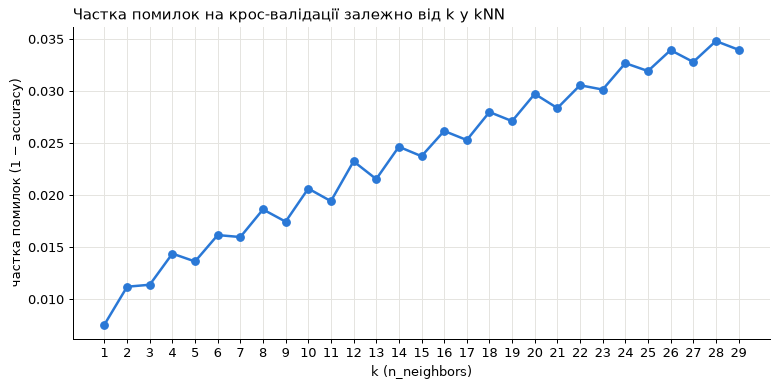

In [183]:
k_values = list(range(1, 30))
knn_cv_error = 1 - knn_grid.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=90)
ax.plot(k_values, knn_cv_error, marker='o', markersize=6, linewidth=2, color='#2a78d6')
ax.set_title('Частка помилок на крос-валідації залежно від k у kNN', loc='left', fontsize=12)
ax.set_xlabel('k (n_neighbors)')
ax.set_ylabel('частка помилок (1 − accuracy)')
ax.set_xticks(k_values)
ax.grid(color='#e5e4e0', linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.show()

**Висновок:**
- Помилка найменша при **k = 1** (точність на крос-валідації 99.25 %) і з ростом k майже рівномірно зростає (при k = 29 точність 96.6 %).
-  Причина в структурі даних: записи одного класу утворюють щільні групи дуже схожих точок (сусідні часові вікна того самого трафіку),
  тож найближчий сусід майже завжди належить тому самому класу. Більше k «затягує» сусідів зі схожих класів (`gafgyt_combo` / `gafgyt_junk`, `mirai_ack` / `mirai_udp`).
- Обираємо **k = 1**, як визначив GridSearchCV. Майже так само добре працює k = 3 (98.86 %), якщо потрібна стійкіша до шуму модель.

### Підбір C і gamma для SVM за допомогою GridSearchCV

In [186]:
param_grid = {'C': [0.1, 1, 10, 100, 1000, 10000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf']}

svm_grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)

start = time.perf_counter()
svm_grid.fit(X_train_scaled, y_train)
print(f'Час пошуку: {(time.perf_counter() - start) / 60:.1f} хв')

print('Найкращі параметри:', svm_grid.best_params_)
print(f'Accuracy на крос-валідації: {svm_grid.best_score_:.4f}')

Час пошуку: 13.6 хв
Найкращі параметри: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Accuracy на крос-валідації: 0.9201


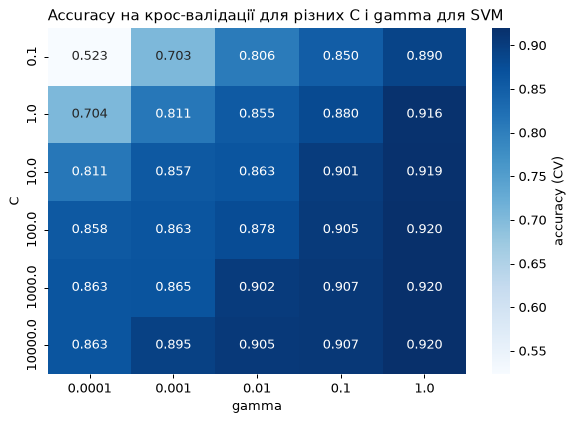

In [202]:
svm_scores = pd.DataFrame(svm_grid.cv_results_).pivot(index='param_C', columns='param_gamma', values='mean_test_score')

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=90)
sns.heatmap(svm_scores, annot=True, fmt='.3f', cmap='Blues', cbar_kws={'label': 'accuracy (CV)'}, ax=ax)
ax.set_title('Accuracy на крос-валідації для різних C і gamma для SVM', loc='left', fontsize=12)
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.show()

- Точність зростає зі збільшенням і `C`, і `gamma`. Найкраща комбінація: **C = 1000, gamma = 1**, точність на крос-валідації **92.01 %**.
  Для порівняння, базовий SVM (`C = 1`, `gamma = 'scale'` ≈ 0.009) мав ≈ 86 %.
- Мале `C` разом із малим `gamma` (лівий верхній кут, 52 %) дає занадто згладжену межу, яка не встигає за складною структурою 11 класів (недонавчання).
- Навіть найкращий SVM помітно слабший за дерева (≈ 92 % проти ≈ 99.8 %).
- Цей пошук триває найдовше серед усіх моделей

### Вплив max_depth для Decision Tree

`max_depth` обмежує кількість послідовних питань у дереві. Перевіримо глибину від 1 до 20 і без обмеження (`None`).

In [203]:
depths = list(range(1, 25)) + [None]
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {'max_depth': depths}, cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)

print('Найкраще max_depth:', dt_grid.best_params_['max_depth'])
print(f'Accuracy на крос-валідації: {dt_grid.best_score_:.4f}')
print(f"Без обмеження глибини (None): {dt_grid.cv_results_['mean_test_score'][-1]:.4f}")

Найкраще max_depth: 20
Accuracy на крос-валідації: 0.9981
Без обмеження глибини (None): 0.9981


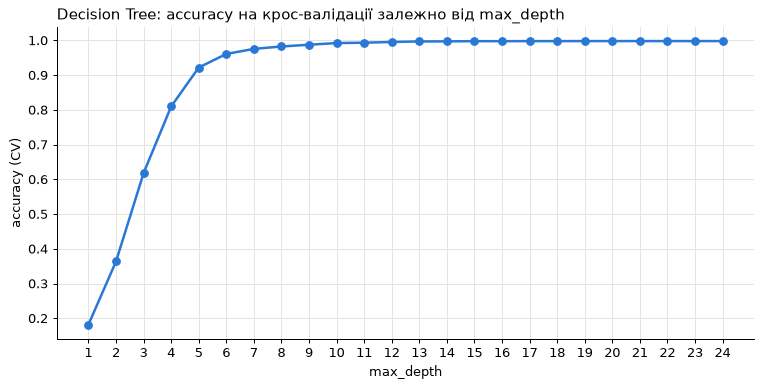

In [204]:
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=90)
ax.plot(depths[:-1], dt_grid.cv_results_['mean_test_score'][:-1], marker='o', markersize=6, linewidth=2, color='#2a78d6')
ax.set_title('Decision Tree: accuracy на крос-валідації залежно від max_depth', loc='left', fontsize=12)
ax.set_xlabel('max_depth')
ax.set_ylabel('accuracy (CV)')
ax.set_xticks(depths[:-1])
ax.grid(color='#e5e4e0', linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.show()

**Висновок:**
- Точність швидко зростає з глибиною: 1 рівень дає 18 %, 5 рівнів 92 %, 10 рівнів 99.2 %, а приблизно з 15 рівнів виходить на плато ≈ 99.8 %.
- При глибині 1 дерево має лише 2 листки, тобто може передбачати не більше 2 з 11 класів (2/11 ≈ 18 %). При глибині 2 - 4 листки (≈ 36 %). Кожен новий рівень подвоює кількість можливих листків.
- `max_depth = 20` і без обмеження (`None`) дають однаковий результат (99.81 %), бо дерево без обмеження й так виростає лише до глибини 18.
  Тобто обмеження глибини тут не впливає на результат, і перенавчання не видно: точність на крос-валідації з глибиною не падає.

### Вплив глибини базового дерева для AdaBoost

In [205]:
ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=50, random_state=42),
    {'estimator__max_depth': [1, 2, 3, 4, 5]}, cv=5, n_jobs=-1)
ada_grid.fit(X_train, y_train)

print('Найкраща глибина базового дерева:', ada_grid.best_params_['estimator__max_depth'])
print(f'Accuracy на крос-валідації: {ada_grid.best_score_:.4f}')

Найкраща глибина базового дерева: 5
Accuracy на крос-валідації: 0.9991


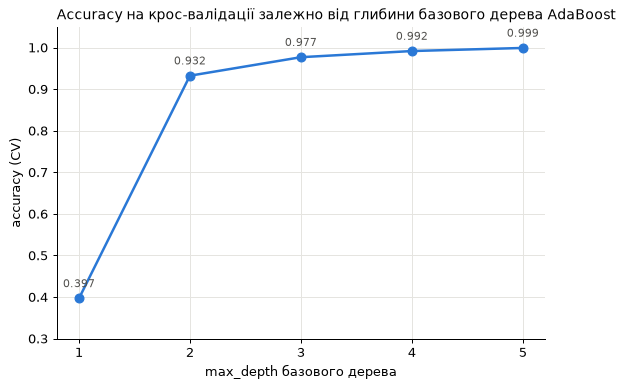

In [206]:
ada_depths = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=90)
ax.plot(ada_depths, ada_grid.cv_results_['mean_test_score'], marker='o', markersize=7, linewidth=2, color='#2a78d6')
for d, s in zip(ada_depths, ada_grid.cv_results_['mean_test_score']):
    ax.annotate(f'{s:.3f}', (d, s), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9, color='#52514e')
ax.set_title('Accuracy на крос-валідації залежно від глибини базового дерева AdaBoost', loc='left', fontsize=11)
ax.set_xlabel('max_depth базового дерева')
ax.set_ylabel('accuracy (CV)')
ax.set_xticks(ada_depths)
ax.set_ylim(0.3, 1.05)
ax.grid(color='#e5e4e0', linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.show()

Глибина базового дерева **критично** впливає на AdaBoost: 1 рівень дає 39.7 %, 2 рівні 93.2 %, 3 рівні 97.7 %, 4 рівні 99.2 %, 5 рівнів **99.9 %**.

### Підсумок підбору гіперпараметрів

In [207]:
tuning_summary = pd.DataFrame({
    'kNN': [str(knn_grid.best_params_), knn_grid.best_score_],
    'SVM': [str(svm_grid.best_params_), svm_grid.best_score_],
    'Decision Tree': [str(dt_grid.best_params_), dt_grid.best_score_],
    'AdaBoost': [str(ada_grid.best_params_), ada_grid.best_score_],
}, index=['найкращі параметри', 'accuracy (CV)']).T
tuning_summary['accuracy (CV)'] = tuning_summary['accuracy (CV)'].astype(float).round(4)
tuning_summary

,найкращі параметри,accuracy (CV)
kNN,{'n_neighbors': 1},0.9924
SVM,"{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}",0.9201
Decision Tree,{'max_depth': 20},0.9981
AdaBoost,{'estimator__max_depth': 5},0.9991


### 7) Порівняння та оцінювання моделей: порівняти результати всіх навчених класифікаторів та визначити найкращу модель для обраного датасета. Для моделей вивести та проаналізувати classification_report і confusion_matrix. Зробити короткий висновок: яка модель показала найкращий результат і чому.

Для фінального оцінювання беремо моделі з найкращими параметрами із завдання 6 (вони вже перенавчені на всьому train),
а Random Forest - із завдання 5. Кожну модель перевіряємо на test-вибірці.


In [208]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

final_models = {
    'kNN': (knn_grid.best_estimator_, X_test_scaled),
    'Decision Tree': (dt_grid.best_estimator_, X_test),
    'SVM': (svm_grid.best_estimator_, X_test_scaled),
    'Random Forest': (rf, X_test),
    'AdaBoost': (ada_grid.best_estimator_, X_test),
}
predictions = {name: model.predict(X_te) for name, (model, X_te) in final_models.items()}


def show_results(name):
    y_pred = predictions[name]
    print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7), dpi=90)
    sns.heatmap(cm, fmt='', cmap='Blues', cbar=False, linewidths=0.5, linecolor='#e5e4e0',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'Confusion matrix: {name}', loc='left', fontsize=12)
    ax.set_xlabel('Передбачений клас')
    ax.set_ylabel('Справжній клас')
    plt.show()

    n_errors = int((y_pred != y_test).sum())
    print(f'Помилок: {n_errors} з {len(y_test)}')
    if n_errors:
        confused = [(le.classes_[i], le.classes_[j], cm[i, j])
                    for i in range(len(cm)) for j in range(len(cm)) if i != j and cm[i, j] > 0]
        confused = pd.DataFrame(confused, columns=['Справжній клас', 'Передбачений клас', 'Кількість'])
        print(confused.sort_values('Кількість', ascending=False).to_string(index=False))

### kNN (k = 1)

                precision    recall  f1-score   support

        benign     0.9917    1.0000    0.9959       600
  gafgyt_combo     0.9917    0.9900    0.9908       600
   gafgyt_junk     0.9884    0.9917    0.9900       600
   gafgyt_scan     0.9967    0.9933    0.9950       600
    gafgyt_tcp     1.0000    0.9967    0.9983       600
    gafgyt_udp     0.9983    0.9983    0.9983       600
     mirai_ack     0.9883    0.9867    0.9875       600
    mirai_scan     1.0000    0.9983    0.9992       600
     mirai_syn     1.0000    0.9983    0.9992       600
     mirai_udp     0.9867    0.9883    0.9875       600
mirai_udpplain     1.0000    1.0000    1.0000       600

      accuracy                         0.9947      6600
     macro avg     0.9947    0.9947    0.9947      6600
  weighted avg     0.9947    0.9947    0.9947      6600



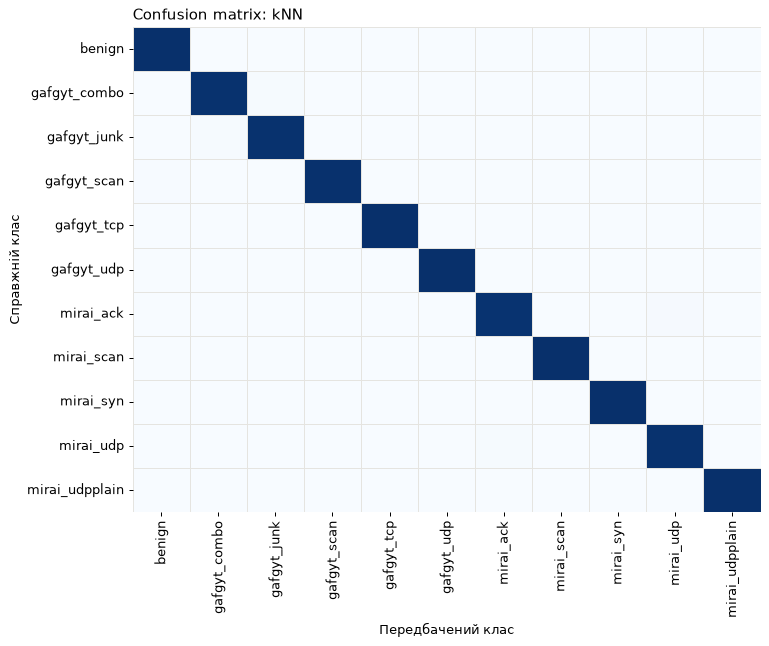

Помилок: 35 з 6600
Справжній клас Передбачений клас  Кількість
     mirai_ack         mirai_udp          8
     mirai_udp         mirai_ack          7
  gafgyt_combo       gafgyt_junk          6
   gafgyt_junk      gafgyt_combo          5
   gafgyt_scan            benign          3
   gafgyt_scan        gafgyt_udp          1
    gafgyt_tcp            benign          1
    gafgyt_udp       gafgyt_scan          1
    gafgyt_tcp       gafgyt_scan          1
    mirai_scan            benign          1
     mirai_syn       gafgyt_junk          1


In [209]:
show_results('kNN')

### Decision Tree

                precision    recall  f1-score   support

        benign     1.0000    0.9983    0.9992       600
  gafgyt_combo     0.9950    0.9917    0.9933       600
   gafgyt_junk     0.9900    0.9950    0.9925       600
   gafgyt_scan     1.0000    1.0000    1.0000       600
    gafgyt_tcp     1.0000    0.9967    0.9983       600
    gafgyt_udp     0.9967    1.0000    0.9983       600
     mirai_ack     1.0000    1.0000    1.0000       600
    mirai_scan     1.0000    1.0000    1.0000       600
     mirai_syn     1.0000    1.0000    1.0000       600
     mirai_udp     1.0000    1.0000    1.0000       600
mirai_udpplain     1.0000    1.0000    1.0000       600

      accuracy                         0.9983      6600
     macro avg     0.9983    0.9983    0.9983      6600
  weighted avg     0.9983    0.9983    0.9983      6600



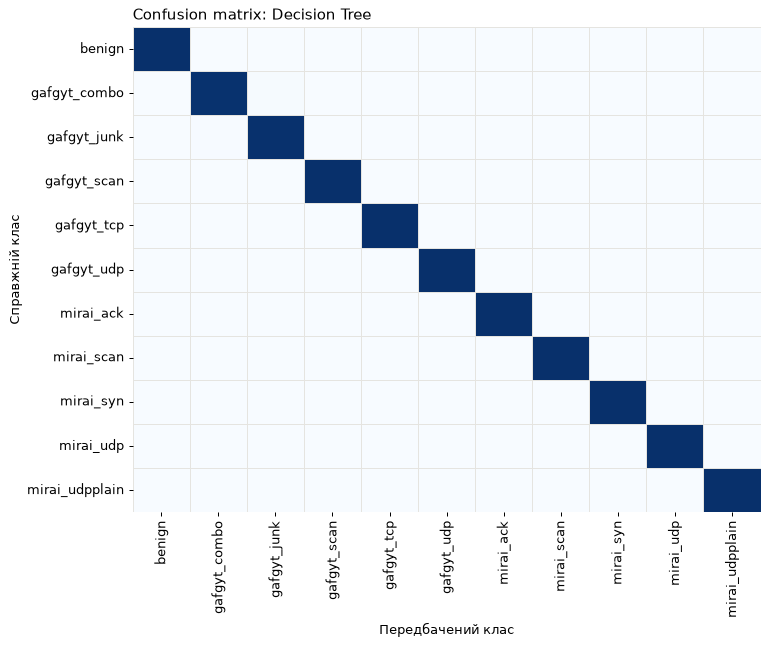

Помилок: 11 з 6600
Справжній клас Передбачений клас  Кількість
  gafgyt_combo       gafgyt_junk          5
   gafgyt_junk      gafgyt_combo          3
        benign        gafgyt_udp          1
    gafgyt_tcp       gafgyt_junk          1
    gafgyt_tcp        gafgyt_udp          1


In [210]:
show_results('Decision Tree')

### SVM

                precision    recall  f1-score   support

        benign     0.9449    1.0000    0.9717       600
  gafgyt_combo     1.0000    0.9950    0.9975       600
   gafgyt_junk     1.0000    0.9983    0.9992       600
   gafgyt_scan     1.0000    0.9867    0.9933       600
    gafgyt_tcp     0.4996    0.9967    0.6656       600
    gafgyt_udp     0.0000    0.0000    0.0000       600
     mirai_ack     0.9966    0.9900    0.9933       600
    mirai_scan     1.0000    0.9983    0.9992       600
     mirai_syn     1.0000    0.9967    0.9983       600
     mirai_udp     1.0000    0.9833    0.9916       600
mirai_udpplain     1.0000    0.9950    0.9975       600

      accuracy                         0.9036      6600
     macro avg     0.8583    0.9036    0.8734      6600
  weighted avg     0.8583    0.9036    0.8734      6600



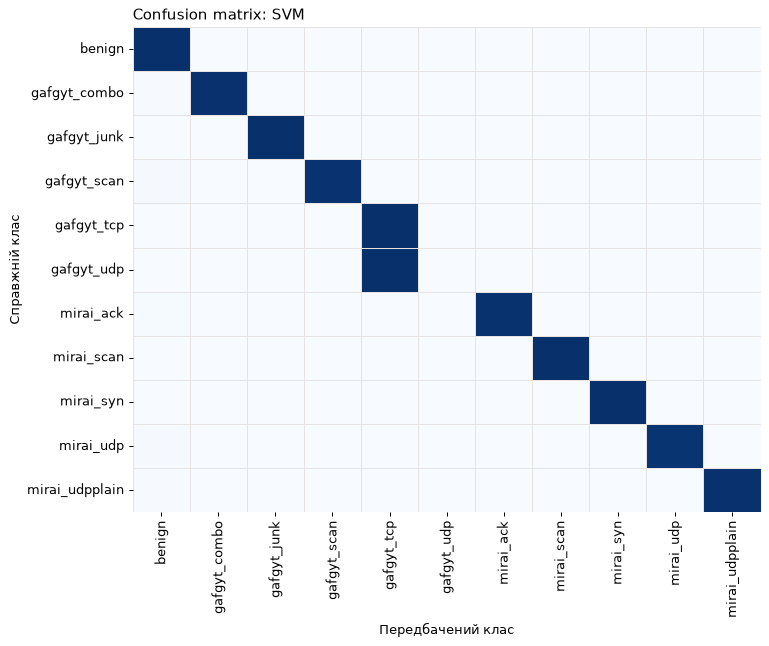

Помилок: 636 з 6600
Справжній клас Передбачений клас  Кількість
    gafgyt_udp        gafgyt_tcp        599
   gafgyt_scan            benign          8
     mirai_udp            benign          8
     mirai_ack            benign          6
  gafgyt_combo            benign          3
mirai_udpplain            benign          3
     mirai_syn            benign          2
    gafgyt_tcp            benign          2
     mirai_udp         mirai_ack          2
   gafgyt_junk            benign          1
    mirai_scan            benign          1
    gafgyt_udp            benign          1


In [211]:
show_results('SVM')

### Random Forest

                precision    recall  f1-score   support

        benign     0.9983    1.0000    0.9992       600
  gafgyt_combo     1.0000    0.9983    0.9992       600
   gafgyt_junk     0.9983    1.0000    0.9992       600
   gafgyt_scan     1.0000    1.0000    1.0000       600
    gafgyt_tcp     1.0000    0.9983    0.9992       600
    gafgyt_udp     0.9983    0.9983    0.9983       600
     mirai_ack     1.0000    1.0000    1.0000       600
    mirai_scan     1.0000    1.0000    1.0000       600
     mirai_syn     1.0000    1.0000    1.0000       600
     mirai_udp     1.0000    1.0000    1.0000       600
mirai_udpplain     1.0000    1.0000    1.0000       600

      accuracy                         0.9995      6600
     macro avg     0.9995    0.9995    0.9995      6600
  weighted avg     0.9995    0.9995    0.9995      6600



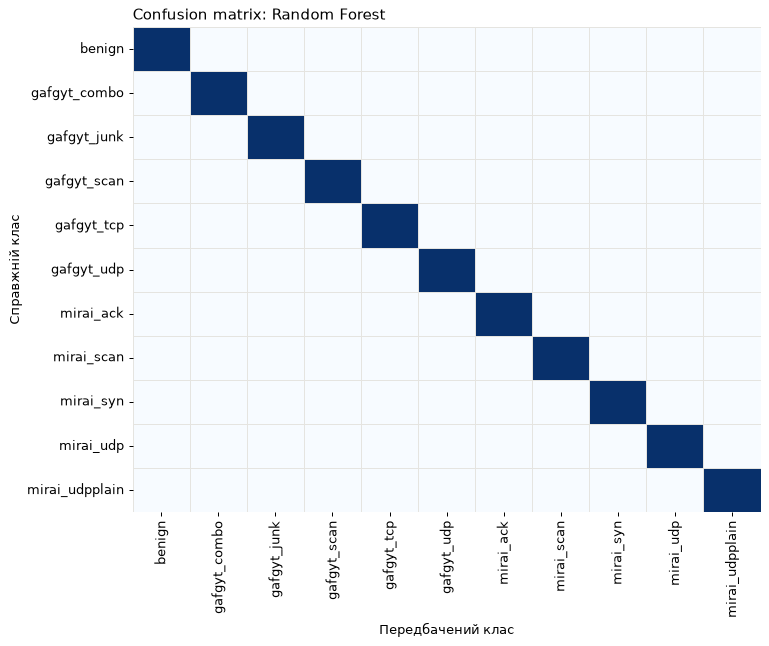

Помилок: 3 з 6600
Справжній клас Передбачений клас  Кількість
  gafgyt_combo       gafgyt_junk          1
    gafgyt_tcp        gafgyt_udp          1
    gafgyt_udp            benign          1


In [212]:
show_results('Random Forest')

### AdaBoost

                precision    recall  f1-score   support

        benign     1.0000    1.0000    1.0000       600
  gafgyt_combo     0.9950    0.9950    0.9950       600
   gafgyt_junk     0.9950    0.9950    0.9950       600
   gafgyt_scan     1.0000    1.0000    1.0000       600
    gafgyt_tcp     1.0000    0.9967    0.9983       600
    gafgyt_udp     0.9983    1.0000    0.9992       600
     mirai_ack     1.0000    1.0000    1.0000       600
    mirai_scan     1.0000    1.0000    1.0000       600
     mirai_syn     1.0000    1.0000    1.0000       600
     mirai_udp     1.0000    1.0000    1.0000       600
mirai_udpplain     0.9983    1.0000    0.9992       600

      accuracy                         0.9988      6600
     macro avg     0.9988    0.9988    0.9988      6600
  weighted avg     0.9988    0.9988    0.9988      6600



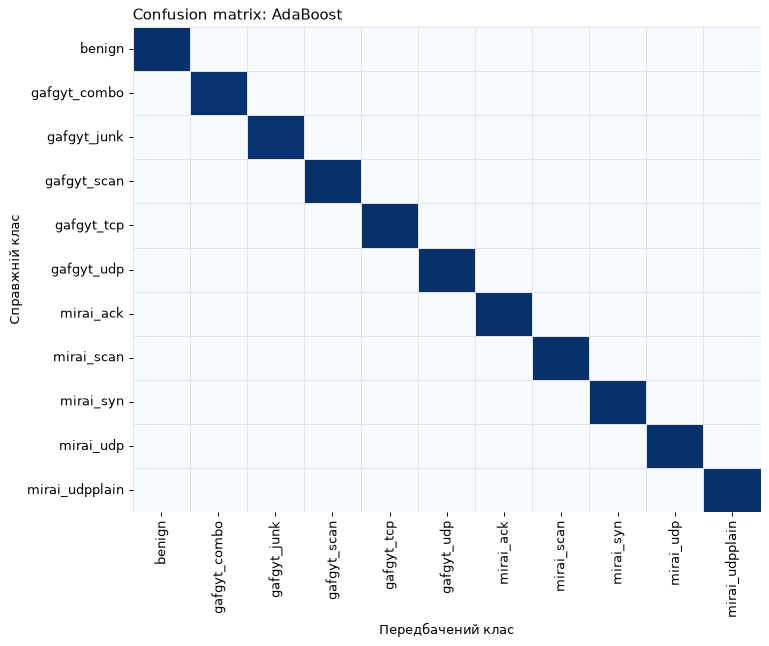

Помилок: 8 з 6600
Справжній клас Передбачений клас  Кількість
  gafgyt_combo       gafgyt_junk          3
   gafgyt_junk      gafgyt_combo          3
    gafgyt_tcp        gafgyt_udp          1
    gafgyt_tcp    mirai_udpplain          1


In [213]:
show_results('AdaBoost')

### Порівняльна таблиця

In [214]:
summary = pd.DataFrame({
    name: {
        'accuracy (завдання 5)': baseline[name]['accuracy (test)'],
        'accuracy': accuracy_score(y_test, y_pred),
        'macro precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'macro recall': recall_score(y_test, y_pred, average='macro'),
        'macro F1': f1_score(y_test, y_pred, average='macro'),
        'помилок (з 6600)': int((y_pred != y_test).sum()),
    }
    for name, y_pred in predictions.items()
}).T.sort_values('macro F1', ascending=False)

summary['помилок (з 6600)'] = summary['помилок (з 6600)'].astype(int)
summary.round(4)

,accuracy (завдання 5),accuracy,macro precision,macro recall,macro F1,помилок (з 6600)
Random Forest,0.9995,0.9995,0.9995,0.9995,0.9995,3
AdaBoost,0.3635,0.9988,0.9988,0.9988,0.9988,8
Decision Tree,0.9983,0.9983,0.9983,0.9983,0.9983,11
kNN,0.9883,0.9947,0.9947,0.9947,0.9947,35
SVM,0.8609,0.9036,0.8583,0.9036,0.8734,636


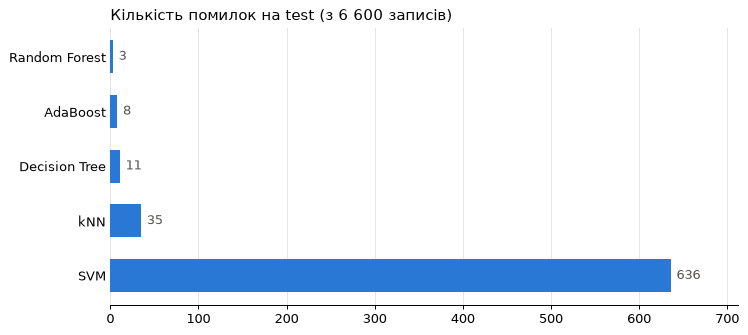

In [215]:
errors = summary['помилок (з 6600)'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4), dpi=90)
bars = ax.barh(errors.index, errors.values, height=0.6, color='#2a78d6')
for bar, n in zip(bars, errors.values):
    ax.text(bar.get_width() + errors.max() * 0.01, bar.get_y() + bar.get_height() / 2, f'{n}',
            va='center', fontsize=10, color='#52514e')
ax.set_title('Кількість помилок на test (з 6 600 записів)', loc='left', fontsize=12)
ax.set_xlim(0, errors.max() * 1.12)
ax.grid(axis='x', color='#e5e4e0', linewidth=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.tick_params(axis='y', length=0)
plt.show()

Які ознаки найважливіші для найкращої моделі Random Forest:

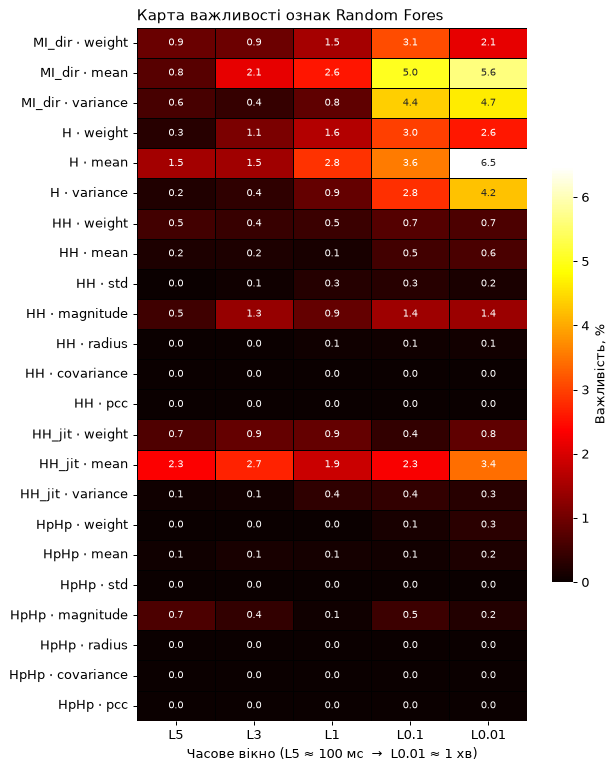

In [216]:
importances_all = pd.Series(rf.feature_importances_, index=feature_cols)

parts = importances_all.index.str.extract(r'^(?P<потік>.+)_L(?P<вікно>[\d.]+)_(?P<статистика>\w+)$')
parts['важливість'] = importances_all.values
parts['ряд'] = parts['потік'] + ' · ' + parts['статистика']

row_order = parts['ряд'].unique()    
col_order = parts['вікно'].unique()   
importance_map = parts.pivot(index='ряд', columns='вікно', values='важливість').loc[row_order, col_order]

fig, ax = plt.subplots(figsize=(7, 10), dpi=90)
sns.heatmap(importance_map * 100, cmap='hot', annot=True, fmt='.1f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='black', cbar_kws={'label': 'Важливість, %', 'shrink': 0.6}, ax=ax)
ax.set_xticklabels([f'L{w}' for w in col_order])
ax.set_xlabel('Часове вікно (L5 ≈ 100 мс  →  L0.01 ≈ 1 хв)')
ax.set_ylabel('')
ax.set_title('Карта важливості ознак Random Fores', loc='left', fontsize=12)
plt.show()

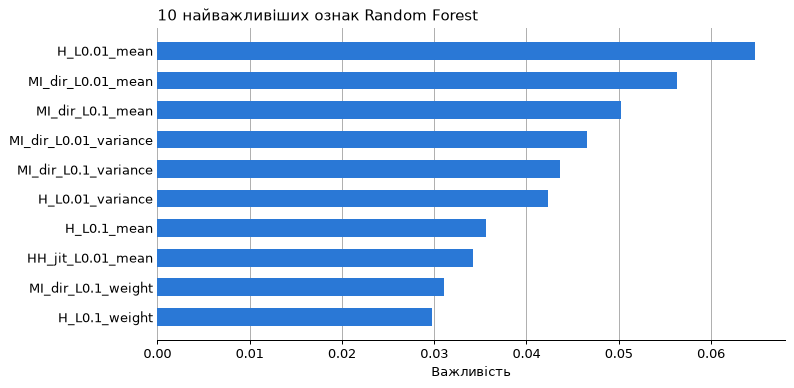

In [217]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=90)
ax.barh(importances.index, importances.values, height=0.6, color='#2a78d6')
ax.set_title('10 найважливіших ознак Random Forest', loc='left', fontsize=12)
ax.set_xlabel('Важливість')
ax.grid(axis='x', linewidth=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.tick_params(axis='y', length=0)
plt.show()

### Додаткова перевірка: як моделі розрізняють gafgyt_tcp і gafgyt_udp?

Класи `gafgyt_tcp` і `gafgyt_udp` на всіх 8 обраних ознаках виглядають однаково,
а ознаки `HH_jit_*_mean` у цих класах містять Unix-час запису (~1.5·10⁹ с).
При цьому Decision Tree, Random Forest і AdaBoost розрізняють ці два класи майже без помилок, а SVM не розрізняє зовсім.

In [218]:
tcp, udp = list(le.classes_).index('gafgyt_tcp'), list(le.classes_).index('gafgyt_udp')
mask = y_train.isin([tcp, udp])

stump = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train[mask], y_train[mask])
split_feature = feature_cols[stump.tree_.feature[0]]
split_threshold = stump.tree_.threshold[0]

print(f'Питання: {split_feature} <= {split_threshold:.0f} ?')
print('Поріг як дата й час (UTC):', pd.to_datetime(split_threshold, unit='s'))
print(f'Точність одного цього питання на tcp vs udp: {stump.score(X_train[mask], y_train[mask]):.4f}')

Питання: HH_jit_L5_mean <= 1505913536 ?
Поріг як дата й час (UTC): 2017-09-20 13:18:56
Точність одного цього питання на tcp vs udp: 0.9994


Тепер навчимо Random Forest **без 15 ознак `HH_jit`**, тобто без ознак, що містять час запису:

In [219]:
no_jit_cols = [c for c in feature_cols if not c.startswith('HH_jit')]

rf_no_jit = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_no_jit.fit(X_train[no_jit_cols], y_train)
y_pred_no_jit = rf_no_jit.predict(X_test[no_jit_cols])

print(f'Ознак: {len(no_jit_cols)}')
print(f'Accuracy без HH_jit: {accuracy_score(y_test, y_pred_no_jit):.4f}\n')
print(classification_report(y_test, y_pred_no_jit, target_names=le.classes_, digits=4, zero_division=0))

Ознак: 100
Accuracy без HH_jit: 0.9089

                precision    recall  f1-score   support

        benign     0.9983    1.0000    0.9992       600
  gafgyt_combo     1.0000    0.9983    0.9992       600
   gafgyt_junk     0.9983    1.0000    0.9992       600
   gafgyt_scan     1.0000    1.0000    1.0000       600
    gafgyt_tcp     0.5004    1.0000    0.6670       600
    gafgyt_udp     0.0000    0.0000    0.0000       600
     mirai_ack     1.0000    1.0000    1.0000       600
    mirai_scan     1.0000    1.0000    1.0000       600
     mirai_syn     1.0000    1.0000    1.0000       600
     mirai_udp     1.0000    1.0000    1.0000       600
mirai_udpplain     1.0000    1.0000    1.0000       600

      accuracy                         0.9089      6600
     macro avg     0.8634    0.9089    0.8786      6600
  weighted avg     0.8634    0.9089    0.8786      6600



**Результат перевірки:**
- Одне питання **«`HH_jit_L5_mean` ≤ 1 505 913 536?»** відділяє `gafgyt_tcp` від `gafgyt_udp` з точністю 99.94 %.
  Поріг - це **20.09.2017, 13:18:56 UTC**: атаку `gafgyt_udp` записали до цього моменту, а `gafgyt_tcp` після.
  Тобто дерева розрізняють ці класи **за часом запису**, а не за поведінкою трафіку.
- Без ознак `HH_jit` Random Forest має accuracy **90.89 %**: **усі** записи `gafgyt_udp` він відносить до `gafgyt_tcp`, а решта 9 класів розпізнаються майже ідеально.
  Отже, за справжніми характеристиками трафіку ці дві flood-атаки на цьому пристрої **не відрізняються**.
- Це пояснює й поведінку SVM. Після `StandardScaler` значення часу обох класів стали однаковими до 6-го знака після коми (≈ 1.142321),
  тому RBF-ядро, яке працює з відстанями, цієї різниці «не бачить». Дерева ж порівнюють з порогом вихідні значення (≈ 1.5·10⁹) і різницю в кілька хвилин помічають.
- **Висновок:** майже ідеальна точність дерев на парі `gafgyt_tcp` / `gafgyt_udp` пов'язана з артефактом датасету (data leakage через час запису).
  На нових даних, записаних в інший час, ця перевага зникла б. Чесна оцінка для реальної системи: 10 класів розпізнаються майже ідеально, а ці дві атаки слід об'єднати в один клас «gafgyt flood».

### Висновки 

| Місце | Модель | Accuracy | Macro F1 | Помилок з 6 600 |
|---|---|---|---|---|
| 1 | **Random Forest** | **99.95 %** | **0.9995** | **3** |
| 2 | AdaBoost (глибина 5) | 99.88 % | 0.9988 | 8 |
| 3 | Decision Tree | 99.83 % | 0.9983 | 11 |
| 4 | kNN (k = 1) | 99.47 % | 0.9947 | 35 |
| 5 | SVM (C = 1000, gamma = 1) | 90.36 % | 0.8734 | 636 |

**Найкраща модель - Random Forest.** Вона помилилася лише на 3 записах з 6 600, і для цього не знадобилося налаштування параметрів.

1. **Структура даних «порогова».** Класи відрізняються конкретними значеннями кількості й розміру пакетів
   (наприклад, 60 байт у Gafgyt tcp/udp, ≈ 390 байт у Mirai ack, ≈ 30 пакетів за хвилину в нормальному трафіку).
   Дерева рішень природно описують дані правилами «ознака ≤ поріг», тому всі три деревні моделі (RF, AdaBoost, DT) зайняли перші місця.
2. **Ансамбль стабільніший за одне дерево.** 100 дерев, навчених на різних випадкових вибірках і підмножинах ознак, помиляються по-різному, і голосування ці помилки згладжує.
   Звідси 3 помилки проти 11 в одного дерева, насамперед у складній парі `gafgyt_combo` / `gafgyt_junk`.
3. **Нечутливість до масштабу, «важких хвостів» і надлишкових ознак.** Ознаки мають масштаби від 10⁻³ до 10¹⁷ і сильно корелюють між собою.
   Деревам масштабування не потрібне, а дублікати ознак їм не заважають. Для kNN і SVM, які працюють з відстанями, це створює проблеми.
4. **Швидкість та інтерпретованість.** Навчання триває кілька секунд.
   Найважливіші ознаки (середній розмір пакетів і його дисперсія в довгих вікнах `H` / `MI_dir`) збігаються з висновками EDA.

**Інші моделі:**
- **AdaBoost** майже наздогнав RF, але лише після збільшення глибини базового дерева.
- **kNN** добре працює на щільних групах схожих записів (k = 1), але плутає схожі атаки (`combo` / `junk`, `ack` / `udp`).
- **SVM** - найслабша модель. Він не розрізняє `gafgyt_tcp` і `gafgyt_udp` і частину атак помилково вважає нормальним трафіком.

**Застереження.** Ідеальне розрізнення `gafgyt_tcp` і `gafgyt_udp` деревними моделями спирається на артефакт датасету: час запису в ознаках `HH_jit`.
Без цих ознак Random Forest має 90.89 %, і всі помилки припадають саме на цю пару. За реальною поведінкою трафіку ці дві атаки для цього пристрою не відрізняються.